In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ratings = pd.read_csv('data/ratings.csv')

In [3]:
movies = pd.read_csv('data/movies.csv')

In [4]:
print("--- Ratings Data ---")
ratings.head()

--- Ratings Data ---


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [5]:
print("\n--- Movies Data ---")
movies.head()


--- Movies Data ---


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Exploratory Data Analysis

In [6]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
n_users = ratings['userId'].nunique()

print(f"Number of ratings: {n_ratings}")
print(f"Number of movies: {n_movies}")
print(f"Number of users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings / n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings / n_movies, 2)}")

Number of ratings: 32000204
Number of movies: 84432
Number of users: 200948
Average number of ratings per user: 159.25
Average number of ratings per movie: 379.01


Distribution of movie ratings

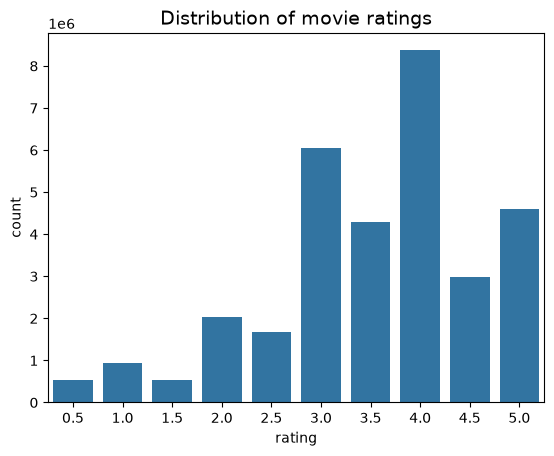

In [7]:
sns.countplot(data=ratings, x='rating')
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

In [8]:
print(f"Mean global rating: {round(ratings['rating'].mean() ,2)}")

Mean global rating: 3.54


In [9]:
mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean ratings per user: {round(mean_ratings.mean(), 2)}")

Mean ratings per user: 3.7


Which movies are most frequently rated?

In [10]:
ratings['movieId'].value_counts()

movieId
318       102929
356       100296
296        98409
2571       93808
593        90330
           ...  
137537         1
150562         1
175771         1
157917         1
274343         1
Name: count, Length: 84432, dtype: int64

In [11]:
movie_ratings = ratings.merge(movies, on="movieId")
movie_ratings['title'].value_counts()[0:10]

title
Shawshank Redemption, The (1994)                             102929
Forrest Gump (1994)                                          100296
Pulp Fiction (1994)                                           98409
Matrix, The (1999)                                            93808
Silence of the Lambs, The (1991)                              90330
Star Wars: Episode IV - A New Hope (1977)                     85010
Fight Club (1999)                                             77332
Jurassic Park (1993)                                          75233
Schindler's List (1993)                                       73849
Lord of the Rings: The Fellowship of the Ring, The (2001)     73122
Name: count, dtype: int64

Shawshank Redemption, Forrest Gump, and Pulp Fiction have the most ratings.

What are the lowest and highest rated movies?

In [12]:
mean_ratings = movie_ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
movies[movies['movieId'] == lowest_rated]

,movieId,title,genres
5694,5805,Besotted (2001),Drama


In [13]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
9644,31945,Always a Bridesmaid (2000),Documentary


How many ratings does "Always a Bridesmaid (2000)" have?

In [14]:
ratings[ratings['movieId'] == highest_rated]

,userId,movieId,rating,timestamp
14497441,90716,31945,5.0,1553102189


"Always a Bridesmaid (2000)" may be the "highest rated movie", but it has only 1 rating. A better aproach for evaluating movie popularity is to do look at the Bayesian average.

Bayesian Average is defined as:

$$\text{Bayesian Average} = \frac{C \cdot m + \sum(x)}{C + n}$$

- C represents "the typical data set size". In this case, C will be the average number of ratings for a given movie.
- m represents the average rating across all movies.
- n represents the number of ratings for a given movie.
- x represents an individual rating.

In [15]:
movie_stats = ratings.groupby('movieId')['rating'].agg(['count', 'mean'])
movie_stats.head()

,count,mean
movieId,,
1,68997,3.897438
2,28904,3.275758
3,13134,3.139447
4,2806,2.845331
5,13154,3.059602


In [16]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

print(f"Average number of ratings for a given movie: {C:.2f}")
print(f"Average rating for a given movie: {m:.2f}")

def bayesian_avg(ratings):
    bayesian_avg = (C * m + ratings.sum()) / (C + ratings.count())
    return round(bayesian_avg, 3)

Average number of ratings for a given movie: 379.01
Average rating for a given movie: 3.01


Let's test our bayesian_avg function out on "Always a Bridesmaid (2000)".

In [17]:
bridesmaid = pd.Series([5])
bayesian_avg(bridesmaid)

np.float64(3.01)

Let's now apply bayesian_avg to all movies in our dataset.

In [18]:
bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']
movie_stats = movie_stats.merge(bayesian_avg_ratings, on="movieId")

In [19]:
movie_stats.head()

,movieId,count,mean,bayesian_avg
0,1,68997,3.897438,3.893
1,2,28904,3.275758,3.272
2,3,13134,3.139447,3.136
3,4,2806,2.845331,2.864
4,5,13154,3.059602,3.058


In [20]:
movie_stats = movie_stats.merge(movies[['movieId', 'title']])
movie_stats.sort_values(by="bayesian_avg", ascending=False)

,movieId,count,mean,bayesian_avg,title
314,318,102929,4.404614,4.399,"Shawshank Redemption, The (1994)"
840,858,66440,4.317030,4.310,"Godfather, The (1972)"
39306,159817,2948,4.444369,4.280,Planet Earth (2006)
58698,202439,11670,4.312254,4.271,Parasite (2019)
44042,170705,2811,4.426539,4.258,Band of Brothers (2001)
...,...,...,...,...,...
9607,31698,832,1.220553,1.779,Son of the Mask (2005)
11353,50798,1492,1.463137,1.775,Epic Movie (2007)
6465,6587,838,1.204057,1.765,Gigli (2003)
4670,4775,757,1.128798,1.755,Glitter (2001)


Using the Bayesian average, we see that Shawshank Redemption, Godfather, Planet Earth are the most highly rated movies. This result makes much more sense since these movies are critically acclaimed films.

In [21]:
movie_stats.sort_values(by="bayesian_avg", ascending=True).head()

,movieId,count,mean,bayesian_avg,title
3495,3593,5010,1.567265,1.668,Battlefield Earth (2000)
4670,4775,757,1.128798,1.755,Glitter (2001)
6465,6587,838,1.204057,1.765,Gigli (2003)
11353,50798,1492,1.463137,1.775,Epic Movie (2007)
9607,31698,832,1.220553,1.779,Son of the Mask (2005)


With Bayesian averaging, it looks like Battlefield Earth, Glitter, and Gigil are the worst rated movies. Besotted (2001) isn't bad at all.

A Glimpse at Movie Genres
-

The movies dataset needs to be cleaned in two ways:
- genres is expressed as a string with a pipe | separating each genre. We will manipulate this string into a list, which will make it much easier to analyze.
- title currently has (year) appended at the end. We will extract year from each title string and make a new comlumn for it.

In [22]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [23]:
movies['genres'] = movies['genres'].apply(lambda x: x.split('|'))
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


How many movie genres are there?

In [24]:
from collections import Counter

genre_frequency = Counter(g for genres in movies['genres'] for g in genres)

print(f"There are {len(genre_frequency)} genres.")
genre_frequency

There are 20 genres.


Counter({'Drama': 34175,
         'Comedy': 23124,
         'Thriller': 11823,
         'Romance': 10369,
         'Action': 9668,
         'Documentary': 9363,
         'Horror': 8654,
         '(no genres listed)': 7080,
         'Crime': 6976,
         'Adventure': 5402,
         'Sci-Fi': 4907,
         'Animation': 4617,
         'Children': 4520,
         'Mystery': 4013,
         'Fantasy': 3851,
         'War': 2325,
         'Western': 1696,
         'Musical': 1059,
         'Film-Noir': 353,
         'IMAX': 195})

In [25]:
print(f"The 5 most common genres: \n{genre_frequency.most_common(5)}")

The 5 most common genres: 
[('Drama', 34175), ('Comedy', 23124), ('Thriller', 11823), ('Romance', 10369), ('Action', 9668)]


The top 5 genres are: Drama, Comedy, Thriller, Romance and Action.

Let's also visualize genres popularity with a barplot.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Drama'),
  Text(1, 0, 'Comedy'),
  Text(2, 0, 'Thriller'),
  Text(3, 0, 'Romance'),
  Text(4, 0, 'Action'),
  Text(5, 0, 'Documentary'),
  Text(6, 0, 'Horror'),
  Text(7, 0, '(no genres listed)'),
  Text(8, 0, 'Crime'),
  Text(9, 0, 'Adventure'),
  Text(10, 0, 'Sci-Fi'),
  Text(11, 0, 'Animation'),
  Text(12, 0, 'Children'),
  Text(13, 0, 'Mystery'),
  Text(14, 0, 'Fantasy'),
  Text(15, 0, 'War'),
  Text(16, 0, 'Western'),
  Text(17, 0, 'Musical'),
  Text(18, 0, 'Film-Noir'),
  Text(19, 0, 'IMAX')])

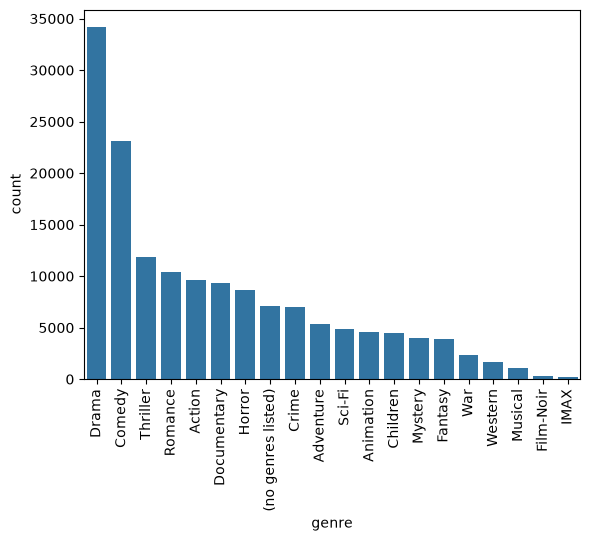

In [26]:
genre_frequency_df = pd.DataFrame([genre_frequency]).T.reset_index()
genre_frequency_df.columns = ['genre', 'count']
genre_frequency_df.head()

sns.barplot(data=genre_frequency_df.sort_values(by='count', ascending=False) , x="genre", y="count")
plt.xticks(rotation=90)

Data Pre-processing
-

We are going to use a technique called collaborative filtering to generate recommendations for users. This technique is based on the premise that similar people like similar things.

The first step is to transform our data into a user-item matrix, also known as a "utility" matrix. In this matrix, rows represent users and columns represent movies. The beauty of collaborative filtering is that it doesn't require any information about the users or the movies to generate recommendations.

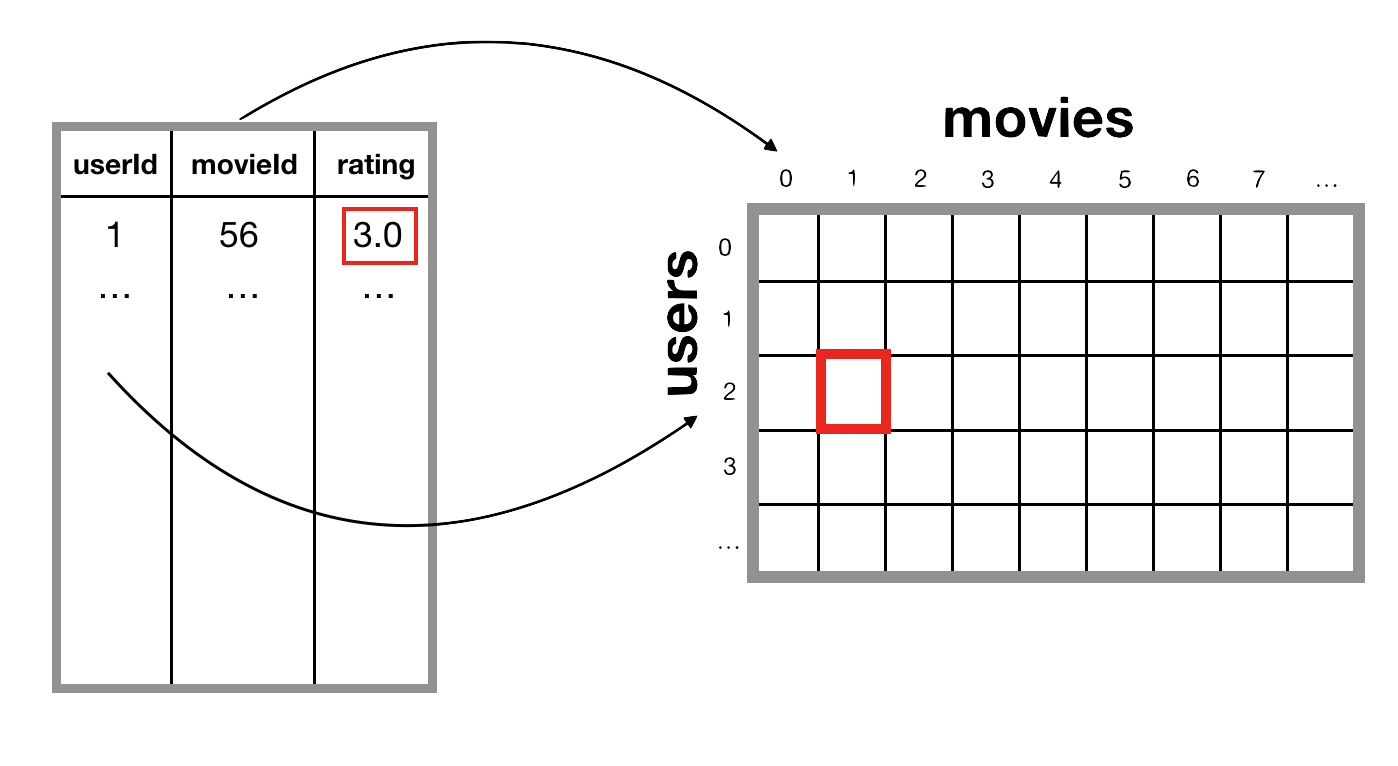

The create_X() function outputs a sparse array X with four mapper dictionaries:

- user_mapper: maps user id to user index
- movie_mapper: maps movie id to movie index
- user_inv_mapper: maps user index to user id
- movie_inv_mapper: maps movie index to movie id

We need these dictionaries because they map which row/column of the utility matrix corresponds to which user/movie id:

Our X (user-item) matrix is scipy sparse.csr matrix which stores the data sparsely.

In [27]:
from scipy.sparse import csr_array

def create_X(df):
    """
    Generates a sparse array from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse array
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    
    # number of users
    M = df['userId'].nunique()
    # number of movies
    N = df['movieId'].nunique()

    # {'user id', 'user index'}
    user_mapper = dict(zip(np.unique(df['userId']), list(range(M))))
    # {'movie id', 'movie index'}
    movie_mapper = dict(zip(np.unique(df['movieId']), list(range(N))))

    # {'user index', 'user id'}
    user_inv_mapper = dict(zip(list(range(M)), np.unique(df['userId'])))
    # {'movie index', 'movie id'}
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df['movieId'])))

    user_index = [user_mapper[i] for i in df['userId']]
    movie_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_array((df['rating'], (user_index, movie_index)), shape=[M, N])

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(ratings)

In [28]:
X.shape

(200948, 84432)

Evaluating sparsity

Here, we calculate sparsity by the number of stored elements by total nubmers of elements. The number of stored (non-empty) values in our matrix(nnz) is equivalent to the number of ratings in our dataset.

In [29]:
n_total = X.shape[0] * X.shape[1]
n_ratings = X.nnz
sparsity = n_ratings / n_total
print(f"Matrix sparsity: {round(sparsity * 100, 2)}%")

Matrix sparsity: 0.19%
